# GeoPython 2026 — Día 2: El stack vectorial
## Shapely → Fiona → GeoPandas

**Curso de Análisis Espacial con Python**  
Gabinete de Formación del CSIC — Estación Biológica de Doñana, Sevilla

---

> **Entorno recomendado:** Local (entorno `geopython2026`)  
> En Colab: `!pip install geopandas fiona shapely`

## Contenido

1. El stack de librerías vectoriales
2. Shapely — geometrías en Python
3. Fiona — I/O vectorial sobre OGR
4. GeoPandas — análisis vectorial de alto nivel

---
## 1. El stack de librerías vectoriales

Antes de escribir código, conviene entender cómo se relacionan las librerías que vamos a usar.  
Esta jerarquía es uno de los conceptos más importantes del curso:

```
GDAL / OGR  ←  librería C/C++ (~1998). El motor de todo.
    │
    ├── Fiona  ←  wrapper Python de OGR para lectura/escritura (2011)
    │               (GeoPandas ≥ 1.0 usa PyOGRIO internamente)
    │
    └── Shapely  ←  geometrías Python sobre GEOS (2007 → v2.0 en 2022)
            │
            └── GeoPandas  ←  GeoDataFrame = Shapely + Pandas + I/O (2013)
```

**¿Por qué importa esto?**
- Cuando algo falla en GeoPandas, el error suele venir de Shapely o de GDAL.
- Saber qué capa hace qué te permite depurar y elegir la herramienta correcta.
- Fiona y Shapely son útiles solos cuando necesitas control fino; GeoPandas cuando quieres velocidad de desarrollo.

Empezamos por la base y subimos.

---
## 2. Shapely

Shapely implementa el modelo de geometría de la especificación **OGC Simple Features**.  
Trabaja con objetos en memoria, sin CRS: solo coordenadas.

> A partir de la versión 2.0 (2022), Shapely usa **GEOS** de forma vectorizada y es significativamente más rápido.
  GeoPandas ≥ 0.14 requiere Shapely ≥ 2.0.

In [5]:
from shapely.geometry import (
    Point, MultiPoint,
    LineString, MultiLineString,
    Polygon, MultiPolygon,
    GeometryCollection
)
import shapely
print(f'Shapely {shapely.__version__}')

Shapely 2.1.2


In [6]:
pip show shapely

Name: shapely
Version: 2.1.2
Summary: Manipulation and analysis of geometric objects
Home-page: 
Author: Sean Gillies
Author-email: 
License: BSD 3-Clause
Location: C:\Users\dvillegas.AULADEI\AppData\Local\miniconda3\envs\geopython2026\Lib\site-packages
Requires: numpy
Required-by: geopandas, osmnx
Note: you may need to restart the kernel to use updated packages.


### 2.1 Geometrías básicas

Tipo:  Point
WKT:   POINT (711956 4116309)
Coords: [(711956.0, 4116309.0)]
x=711956.0, y=4116309.0


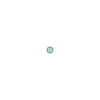

In [7]:
# PUNTO
p = Point(711956, 4116309)   # coordenadas UTM (x, y)
print(f'Tipo:  {p.geom_type}')
print(f'WKT:   {p.wkt}')
print(f'Coords: {list(p.coords)}')
print(f'x={p.x}, y={p.y}')

p

Tipo:     LineString
Longitud: 21.21
Bounds:   (0.0, 0.0, 15.0, 5.0)


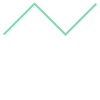

In [8]:
# LÍNEA
linea = LineString([(0, 0), (5, 5), (10, 0), (15, 5)])
print(f'Tipo:     {linea.geom_type}')
print(f'Longitud: {linea.length:.2f}')
print(f'Bounds:   {linea.bounds}')   # (minx, miny, maxx, maxy)
linea

Área sin agujero:  100.0
Área con agujero:  96.0
Perímetro exterior: 40.0
Centroide: POINT (5 5)


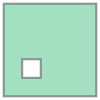

In [9]:
# POLÍGONO: exterior + agujeros (holes)
exterior = [(0, 0), (10, 0), (10, 10), (0, 10)]
agujero  = [(2, 2), (2, 4), (4, 4), (4, 2)]

poligono_simple = Polygon(exterior)
poligono_agujero = Polygon(exterior, holes=[agujero])

print(f'Área sin agujero:  {poligono_simple.area}')
print(f'Área con agujero:  {poligono_agujero.area}')  # 100 - 4 = 96
print(f'Perímetro exterior: {poligono_simple.length}')
print(f'Centroide: {poligono_simple.centroid}')
poligono_agujero

Nº polígonos: 2
Área total:   8.0


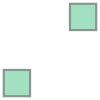

In [10]:
# MULTI-geometrías: agrupan varios objetos del mismo tipo
multipunto = MultiPoint([(0, 0), (5, 5), (10, 0)])
multipoligono = MultiPolygon([
    Polygon([(0, 0), (2, 0), (2, 2), (0, 2)]),
    Polygon([(5, 5), (7, 5), (7, 7), (5, 7)]),
])

print(f'Nº polígonos: {len(list(multipoligono.geoms))}')
print(f'Área total:   {multipoligono.area}')
multipoligono

In [11]:
# Crear desde WKT o WKB (muy útil al leer de bases de datos)
from shapely import wkt, wkb

geom_wkt = wkt.loads('POLYGON ((0 0, 4 0, 4 4, 0 4, 0 0))')
print(geom_wkt.area)

# Serializar
print(geom_wkt.wkt)
print(geom_wkt.wkb.hex()[:30], '...')

16.0
POLYGON ((0 0, 4 0, 4 4, 0 4, 0 0))
010300000001000000050000000000 ...


### 2.2 Atributos geométricos

In [12]:
# Atributos más útiles de un polígono
p = Polygon([(0,0),(10,0),(10,6),(0,6)])

print(f'area:      {p.area}')
print(f'length:    {p.length}')         # perímetro
print(f'bounds:    {p.bounds}')         # (minx, miny, maxx, maxy)
print(f'centroid:  {p.centroid}')
print(f'envelope:  {p.envelope}')       # MBR como polígono
print(f'is_valid:  {p.is_valid}')
print(f'is_empty:  {p.is_empty}')
print(f'geom_type: {p.geom_type}')

area:      60.0
length:    32.0
bounds:    (0.0, 0.0, 10.0, 6.0)
centroid:  POINT (5 3)
envelope:  POLYGON ((0 0, 10 0, 10 6, 0 6, 0 0))
is_valid:  True
is_empty:  False
geom_type: Polygon


In [13]:
# representative_point(): garantizado que cae dentro del polígono
# (el centroide puede caer fuera en formas cóncavas)
c_forma = Polygon([(0,0),(10,0),(10,1),(1,1),(1,9),(10,9),(10,10),(0,10)])

centroide = c_forma.centroid
repr_pt   = c_forma.representative_point()

print(f'Centroide dentro:    {c_forma.contains(centroide)}')
print(f'Repr. point dentro:  {c_forma.contains(repr_pt)}')

Centroide dentro:    False
Repr. point dentro:  True


### 2.3 Operaciones geométricas

In [14]:
# Buffer
punto = Point(5, 5)
circulo = punto.buffer(3)        # por defecto 16 segmentos
circulo_fino = punto.buffer(3, resolution=64)

print(f'Área teórica (π·r²): {3.14159 * 9:.4f}')
print(f'Área buffer 16 seg:  {circulo.area:.4f}')
print(f'Área buffer 64 seg:  {circulo_fino.area:.4f}')

Área teórica (π·r²): 28.2743
Área buffer 16 seg:  28.2289
Área buffer 64 seg:  28.2715


In [15]:
# Operaciones booleanas: intersección, unión, diferencia
A = Polygon([(0,0),(4,0),(4,4),(0,4)])
B = Polygon([(2,2),(6,2),(6,6),(2,6)])

interseccion       = A.intersection(B)
union              = A.union(B)
diferencia_A_B     = A.difference(B)
diferencia_simetrica = A.symmetric_difference(B)

print(f'A área:                 {A.area}')
print(f'B área:                 {B.area}')
print(f'Intersección área:      {interseccion.area}')
print(f'Unión área:             {union.area}')
print(f'Diferencia A-B área:    {diferencia_A_B.area}')
print(f'Dif. simétrica área:    {diferencia_simetrica.area}')

# Verificación: área(A) + área(B) = área(unión) + área(intersección)
print(f'Verificación: {A.area + B.area} == {union.area + interseccion.area}')

A área:                 16.0
B área:                 16.0
Intersección área:      4.0
Unión área:             28.0
Diferencia A-B área:    12.0
Dif. simétrica área:    24.0
Verificación: 32.0 == 32.0


In [16]:
# Otras operaciones útiles
poligono = Polygon([(0,0),(10,0),(8,5),(10,10),(0,10),(2,5)])

print(f'Convex hull:  {poligono.convex_hull}')
print(f'Área original: {poligono.area:.2f}')
print(f'Área hull:     {poligono.convex_hull.area:.2f}')

# simplify: reduce vértices manteniendo forma aproximada
linea_compleja = LineString([(i, i + 0.05*(i%3)) for i in range(100)])
linea_simple   = linea_compleja.simplify(tolerance=0.5)
print(f'\nVértices original:   {len(list(linea_compleja.coords))}')
print(f'Vértices simplificada: {len(list(linea_simple.coords))}')

Convex hull:  POLYGON ((0 0, 0 10, 10 10, 10 0, 0 0))
Área original: 80.00
Área hull:     100.00

Vértices original:   100
Vértices simplificada: 2


### 2.4 Predicados — relaciones topológicas

| Predicado | Significado |
|-----------|-------------|
| `intersects` | Se solapan en al menos un punto |
| `contains` | A contiene completamente a B |
| `within` | B está dentro de A (inverso de contains) |
| `touches` | Comparten borde pero no interior |
| `crosses` | Se cruzan (sin contener) |
| `disjoint` | No tienen ningún punto en común |
| `covers` | A cubre a B (incluye el borde) |
| `equals` | Geométricamente idénticos |

In [17]:
A = Polygon([(0,0),(6,0),(6,6),(0,6)])
B = Polygon([(4,4),(8,4),(8,8),(4,8)])  # se solapa con A
C = Polygon([(1,1),(3,1),(3,3),(1,3)])  # dentro de A
D = Polygon([(7,7),(9,7),(9,9),(7,9)])  # fuera de A
borde = LineString([(6,0),(6,6)])       # en el borde de A

print('A vs B (solapado):')
print(f'  intersects: {A.intersects(B)} | contains: {A.contains(B)} | within: {B.within(A)}')

print('A vs C (C dentro de A):')
print(f'  contains: {A.contains(C)} | within: {C.within(A)} | disjoint: {A.disjoint(C)}')

print('A vs D (disjoint):')
print(f'  disjoint: {A.disjoint(D)} | intersects: {A.intersects(D)}')

print('A vs borde (touches):')
print(f'  touches: {A.touches(borde)} | intersects: {A.intersects(borde)}')

A vs B (solapado):
  intersects: True | contains: False | within: False
A vs C (C dentro de A):
  contains: True | within: True | disjoint: False
A vs D (disjoint):
  disjoint: True | intersects: False
A vs borde (touches):
  touches: True | intersects: True


### 2.5 Shapely 2.0: operaciones vectorizadas

Shapely 2.0 permite operar sobre **arrays de geometrías** de forma eficiente, sin bucles Python.  
GeoPandas usa esto internamente, pero también puedes usarlo directamente.

In [18]:
import numpy as np
import shapely

# Crear 1000 puntos de una vez (sin bucle)
x = np.random.uniform(0, 100, 1000)
y = np.random.uniform(0, 100, 1000)
puntos = shapely.points(x, y)   # array de geometrías

print(f'Tipo: {type(puntos)}, shape: {puntos.shape}')

# Buffer vectorizado: un buffer por punto, todo a la vez
buffers = shapely.buffer(puntos, radius=5)
print(f'Áreas (media): {shapely.area(buffers).mean():.4f}')  # ≈ π·25

# Contener: ¿qué puntos caen dentro de un polígono?
zona = Polygon([(25, 25), (75, 25), (75, 75), (25, 75)])
dentro = shapely.within(puntos, zona)
print(f'Puntos dentro de la zona: {dentro.sum()} de {len(puntos)}')

Tipo: <class 'numpy.ndarray'>, shape: (1000,)


TypeError: buffer() missing 1 required positional argument: 'distance'

---
## 3. Fiona

Fiona es el wrapper Python de la capa **OGR** de GDAL.  
Su filosofía es simple: los archivos vectoriales son colecciones de **features**,  
y cada feature es un diccionario GeoJSON.

**¿Cuándo usar Fiona directamente?**
- Cuando necesitas leer/escribir archivos con control fino del schema.
- Cuando procesas features una a una sin cargar todo en memoria.
- Cuando quieres convertir formatos sin depender de GeoPandas.
- Para entender qué hace GeoPandas por debajo.

In [19]:
import fiona
print(f'Fiona {fiona.__version__}')
print(f'Drivers disponibles: {len(fiona.supported_drivers)}')

# Drivers más comunes
comunes = ['ESRI Shapefile', 'GPKG', 'GeoJSON', 'OpenFileGDB', 'FlatGeobuf']
for d in comunes:
    modo = fiona.supported_drivers.get(d, 'no disponible')
    print(f'  {d:25s}: {modo}')

Fiona 1.10.1
Drivers disponibles: 20
  ESRI Shapefile           : raw
  GPKG                     : raw
  GeoJSON                  : raw
  OpenFileGDB              : raw
  FlatGeobuf               : raw


### 3.1 Abrir y explorar un archivo

In [41]:
import fiona

ruta_fincas = 'C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/fincas_ETRS89.shp'

with fiona.open(ruta_fincas) as src:
    print(f'Driver:      {src.driver}')
    print(f'CRS:         {src.crs}')
    print(f'EPSG:        {src.crs.to_epsg()}')
    print(f'Nº features: {len(src)}')
    print(f'Bounds:      {src.bounds}')
    print(f'\nSchema:')
    for k, v in src.schema.items():
        print(f'  {k}: {v}')

Driver:      ESRI Shapefile
CRS:         EPSG:25829
EPSG:        25829
Nº features: 57
Bounds:      (695451.2972575804, 4075429.7780811936, 752467.5316057053, 4129476.802198926)

Schema:
  properties: {'OBJECTID': 'int:10', 'FINCA': 'str:30', 'TITULARIDA': 'str:20', 'Hectareas': 'float:19.11', 'Shape_Leng': 'float:19.11', 'Shape_Area': 'float:19.11'}
  geometry: Polygon


In [42]:
# Cada feature es un diccionario tipo GeoJSON
with fiona.open(ruta_fincas) as src:
    feature = next(iter(src))   # primera feature

print('Claves:', list(feature.keys()))
print('\nAtributos (properties):')
for k, v in feature['properties'].items():
    print(f'  {k}: {v}')
print('\nGeometría (tipo):', feature['geometry']['type'])
print('Primer anillo (5 primeras coords):', feature['geometry']['coordinates'][0][:5])

Claves: ['geometry', 'id', 'properties']

Atributos (properties):
  OBJECTID: 1
  FINCA: ROCINA
  TITULARIDA: Pública
  Hectareas: 1236.0815064
  Shape_Leng: 27352.7699773
  Shape_Area: 12376853.9711

Geometría (tipo): Polygon
Primer anillo (5 primeras coords): [(711956.8506591379, 4116309.674935784), (711959.7852517797, 4116303.226816528), (711960.3790180911, 4116303.2946903165), (711965.5519167092, 4116303.8831010577), (711969.9515040496, 4116304.4323093356)]


In [43]:
# Iterar sobre features con filtrado
from shapely.geometry import shape

fincas_privadas = []

with fiona.open(ruta_fincas) as src:
    for feature in src:
        if feature['properties']['TITULARIDA'] == 'Privada':
            geom = shape(feature['geometry'])   # dict → geometría Shapely
            fincas_privadas.append({
                'nombre':   feature['properties']['FINCA'],
                'hectareas': feature['properties']['Hectareas'],
                'geom':     geom
            })

print(f'Fincas privadas: {len(fincas_privadas)}')
for f in sorted(fincas_privadas, key=lambda x: x['hectareas'], reverse=True)[:5]:
    print(f"  {f['nombre']:30s} {f['hectareas']:.1f} ha")

Fincas privadas: 24
  VETA LA PALMA                  10746.3 ha
  EL PUNTAL                      3776.3 ha
  RESERVA DEL GUADIAMAR          3270.2 ha
  MARISMA PINAR ALGAIDA          2760.9 ha
  MARISMA Y LOMO DEL GRULLO      2702.5 ha


### 3.2 Escribir un archivo vectorial con Fiona

In [44]:
import os

# Escribir solo las fincas privadas a un nuevo shapefile
ruta_salida = '/tmp/fincas_privadas.shp'

with fiona.open(ruta_fincas) as src:
    schema_original = src.schema
    crs_original    = src.crs

    with fiona.open(ruta_salida, 'w',
                    driver='ESRI Shapefile',
                    schema=schema_original,
                    crs=crs_original) as dst:

        for feature in src:
            if feature['properties']['TITULARIDA'] == 'Privada':
                dst.write(feature)

# Verificar
with fiona.open(ruta_salida) as f:
    print(f'Features escritas: {len(f)}')
    print(f'CRS: {f.crs.to_epsg()}')

DriverIOError: Failed to create file /tmp\fincas_privadas.shp: No error

In [ ]:
# Crear un shapefile desde cero con schema personalizado
from shapely.geometry import mapping   # geometría Shapely → dict GeoJSON

schema_nuevo = {
    'geometry': 'Point',
    'properties': {
        'id':     'int',
        'nombre': 'str',
        'ndvi':   'float'
    }
}

puntos_muestreo = [
    (1, 'P01', Point(711000, 4116000), 0.65),
    (2, 'P02', Point(715000, 4112000), 0.42),
    (3, 'P03', Point(720000, 4118000), 0.78),
]

from fiona.crs import from_epsg

with fiona.open('/tmp/puntos_muestreo.shp', 'w',
                driver='ESRI Shapefile',
                schema=schema_nuevo,
                crs=from_epsg(25829)) as dst:

    for id_, nombre, geom, ndvi in puntos_muestreo:
        dst.write({
            'geometry':   mapping(geom),
            'properties': {'id': id_, 'nombre': nombre, 'ndvi': ndvi}
        })

print('Shapefile de puntos creado')

---
## 4. GeoPandas

GeoPandas extiende Pandas con una columna especial de geometrías (`geometry`).  
Un `GeoDataFrame` es esencialmente un DataFrame donde cada fila tiene:
- Sus atributos alfanuméricos (columnas normales de Pandas)
- Una geometría Shapely

Internamente usa Shapely para las operaciones y GDAL/PyOGRIO para la I/O.

In [45]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
print(f'GeoPandas {gpd.__version__}')

GeoPandas 1.1.3


### 4.1 Leer y escribir archivos

In [53]:
# read_file() soporta shapefile, GeoPackage, GeoJSON, FlatGeobuf...
#fincas = gpd.read_file('C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/fincas_ETRS89.shp')
andalucia = gpd.read_file('C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/13_01_TerminoMunicipal.shp')
print(type(fincas))
print(fincas.shape)
fincas.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
(57, 10)


,OBJECTID,FINCA,TITULARIDA,Hectareas,Shape_Leng,Shape_Area,geometry,area_ha,perimetro,centroide
0,1,ROCINA,Pública,1236.081506,27352.769977,1.237685e+07,"POLYGON ((711956.851 4116309.675, 711959.785 4...",1236.065432,27334.818737,POINT (716918.194 4114237.462)
1,2,MANECORRO,Pública,14.817218,1510.912287,1.483424e+05,"POLYGON ((722974.231 4111420.866, 722964.46 41...",14.817036,1510.037163,POINT (722676.24 4111381.928)
2,3,MADRE,Pública,206.099286,6840.495031,2.063299e+06,"POLYGON ((724385.301 4111693.064, 724395.333 4...",206.096718,6836.631034,POINT (723826.392 4111543.322)
3,4,SOTOS DE DOÑANA,Pública,898.463463,13851.372449,8.994692e+06,"POLYGON ((726144.117 4107988.363, 725909.165 4...",898.452757,13843.549512,POINT (723916.422 4108653.603)
4,5,MATASGORDA Y CAÑADA MAYOR,Pública,1833.774088,17752.935873,1.835615e+07,"POLYGON ((730937.401 4112839.843, 730957.771 4...",1833.753790,17743.954685,POINT (728200.374 4111520.781)


In [47]:
# La columna 'geometry' contiene objetos Shapely
print(type(fincas['geometry'][0]))     # shapely.geometry.Polygon
print(fincas['geometry'].geom_type.value_counts())
print(f'\nCRS: {fincas.crs}')
print(f'EPSG: {fincas.crs.to_epsg()}')
print(f'Bounds:\n{fincas.total_bounds}')  # [minx, miny, maxx, maxy]

<class 'shapely.geometry.polygon.Polygon'>
Polygon         51
MultiPolygon     6
Name: count, dtype: int64

CRS: EPSG:25829
EPSG: 25829
Bounds:
[ 695451.29725758 4075429.77808119  752467.53160571 4129476.80219893]


In [50]:
# Acceso a atributos de Shapely desde la columna geometry
fincas['area_ha']   = fincas.geometry.area / 10000     # m² → ha
fincas['perimetro'] = fincas.geometry.length
fincas['centroide'] = fincas.geometry.centroid

#print(fincas[['FINCA', 'TITULARIDA', 'Hectareas', 'area_ha']].head(8).to_string())
print(fincas[['FINCA', 'TITULARIDA', 'Shape_Leng', 'perimetro']].head(8).to_string())

                       FINCA TITULARIDA    Shape_Leng     perimetro
0                     ROCINA    Pública  27352.769977  27334.818737
1                  MANECORRO    Pública   1510.912287   1510.037163
2                      MADRE    Pública   6840.495031   6836.631034
3            SOTOS DE DOÑANA    Pública  13851.372449  13843.549512
4  MATASGORDA Y CAÑADA MAYOR    Pública  17752.935873  17743.954685
5                   EL PINTO    Pública   7276.274695   7272.524875
6              LOS MIMBRALES    Pública   6894.974496   6890.900999
7                    NAJARSA    Pública   6245.137985   6241.392875


In [54]:
# Escribir a distintos formatos
andalucia.to_file('C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/andalucia.gpkg', driver='GPKG', layer='municipios')
andalucia.to_file('C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/andalucia.geojson', driver='GeoJSON')

# Leer el GeoPackage
andalucia_gpkg = gpd.read_file('C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/andalucia.gpkg', layer='municipios')
print(f'Leídas desde GPKG: {len(andalucia_gpkg)} features')

Leídas desde GPKG: 785 features


### 4.2 CRS y reproyecciones

El CRS (Coordinate Reference System) es fundamental en análisis espacial.  
GeoPandas usa **pyproj** internamente para gestionar proyecciones.

In [55]:
# Ver el CRS completo
print(fincas.crs)
print(f'\nProj4: {fincas.crs.to_proj4()}')
print(f'WKT (resumido): {fincas.crs.name}')
print(f'Es geográfico: {fincas.crs.is_geographic}')
print(f'Es proyectado: {fincas.crs.is_projected}')
print(f'Unidades: {fincas.crs.axis_info[0].unit_name}')

EPSG:25829

Proj4: +proj=utm +zone=29 +ellps=GRS80 +units=m +no_defs +type=crs
WKT (resumido): ETRS89 / UTM zone 29N
Es geográfico: False
Es proyectado: True
Unidades: metre


C:\Users\dvillegas.AULADEI\AppData\Local\miniconda3\envs\geopython2026\Lib\site-packages\pyproj\crs\crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


In [56]:
# Reproyectar: to_crs()
fincas_geo  = fincas.to_crs(epsg=4326)   # WGS84 geográfico
fincas_etrs = fincas.to_crs(epsg=25830)  # ETRS89 UTM zona 30N

print('Original (EPSG:25829):')
print(f'  {fincas.geometry[0].centroid}')

print('En WGS84 (EPSG:4326):')
print(f'  {fincas_geo.geometry[0].centroid}')

print('En UTM 30N (EPSG:25830):')
print(f'  {fincas_etrs.geometry[0].centroid}')

Original (EPSG:25829):
  POINT (716918.194443605 4114237.4615164255)
En WGS84 (EPSG:4326):
  POINT (-6.557489242023558 37.14938206641995)
En UTM 30N (EPSG:25830):
  POINT (184034.33995832672 4117372.516860601)


In [57]:
# ¡Siempre en el mismo CRS antes de operar!
# Esto fallará (o dará resultados sin sentido):
islas = gpd.read_file('C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/CanaryIslands_exploded_etrs.shp')
print(f'Fincas CRS:  {fincas.crs.to_epsg()}')
print(f'Islas CRS:   {islas.crs.to_epsg()}')

# Solución: reproyectar a un CRS común
islas_utm = islas.to_crs(epsg=25830)
fincas_utm = fincas.to_crs(epsg=25830)
print('\nAmbas en EPSG:25830 ✓')

Fincas CRS:  25829
Islas CRS:   4083

Ambas en EPSG:25830 ✓


### 4.3 Selección y filtrado

In [58]:
# Filtrado atributual (igual que Pandas)
publicas  = fincas[fincas['TITULARIDA'] == 'Pública']
privadas  = fincas[fincas['TITULARIDA'] == 'Privada']
grandes   = fincas[fincas['Hectareas'] > 500]

print(f'Públicas:  {len(publicas)}')
print(f'Privadas:  {len(privadas)}')
print(f'> 500 ha:  {len(grandes)}')

Públicas:  32
Privadas:  24
> 500 ha:  34


In [59]:
# Filtrado espacial con cx (coordinate indexer)
# Seleccionar features dentro de un bounding box
minx, miny, maxx, maxy = 710000, 4110000, 720000, 4120000
fincas_bbox = fincas.cx[minx:maxx, miny:maxy]
print(f'Fincas en el bbox: {len(fincas_bbox)}')

Fincas en el bbox: 2


In [60]:
# Consulta espacial con clip (recortar al contorno exacto)
# Creamos un polígono de recorte
from shapely.geometry import box

rectangulo = gpd.GeoDataFrame(
    geometry=[box(710000, 4110000, 720000, 4120000)],
    crs=fincas.crs
)

fincas_clip = gpd.clip(fincas, rectangulo)
print(f'Features recortadas: {len(fincas_clip)}')
print(f'Área total recortada: {fincas_clip.geometry.area.sum()/10000:.1f} ha')

Features recortadas: 2
Área total recortada: 1760.8 ha


In [61]:
fincas_clip

,OBJECTID,FINCA,TITULARIDA,Hectareas,Shape_Leng,Shape_Area,geometry,area_ha,perimetro,centroide
45,46,ABALARIO,Pública,15411.208015,103587.704495,1.543566e+08,"MULTIPOLYGON (((711458.802 4115418.248, 711454...",15410.961260,103503.792630,POINT (706188.568 4109578.132)
0,1,ROCINA,Pública,1236.081506,27352.769977,1.237685e+07,"POLYGON ((711959.785 4116303.227, 711960.379 4...",1236.065432,27334.818737,POINT (716918.194 4114237.462)


<Axes: >

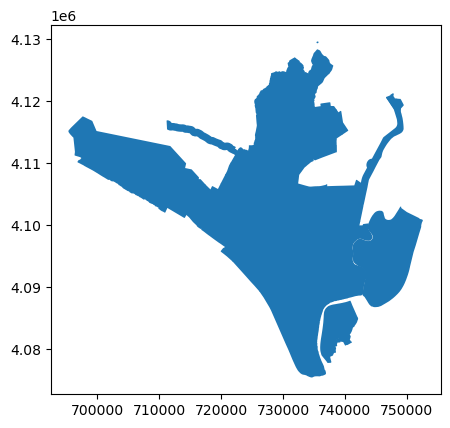

In [72]:
fincas_buf.plot()

### 4.4 Operaciones espaciales

In [71]:
# Buffer colectivo sobre todo el GeoDataFrame
fincas_buf = fincas.copy()
fincas_buf['geometry'] = fincas.geometry.buffer(100)  # 100 metros

print(f'Área media original: {fincas.geometry.area.mean()/10000:.1f} ha')
print(f'Área media buffered: {fincas_buf.geometry.area.mean()/10000:.1f} ha')

Área media original: 1851.7 ha
Área media buffered: 2033.2 ha


               Hectareas  n_fincas
TITULARIDA                        
Privada     33517.358170        24
Privadca      977.485778         1
Pública     71052.292151        32


<Axes: >

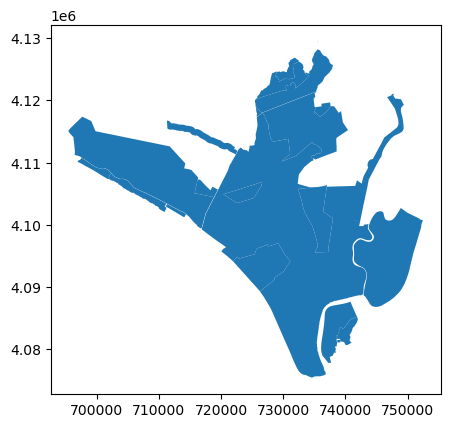

In [73]:
# Dissolve: fusionar features por atributo
# Agrupa todas las fincas por titularidad y las fusiona
titularidad = fincas.dissolve(by='TITULARIDA', aggfunc={
    'Hectareas': 'sum',
    'FINCA': 'count'
}).rename(columns={'FINCA': 'n_fincas'})

print(titularidad[['Hectareas', 'n_fincas']])
titularidad.geometry.plot()

In [74]:
# Overlay: operaciones entre dos GeoDataFrames
# intersection, union, difference, symmetric_difference, identity

# Crear dos capas de ejemplo
zona_norte = gpd.GeoDataFrame(
    geometry=[box(700000, 4115000, 740000, 4130000)], crs=fincas.crs)
zona_sur   = gpd.GeoDataFrame(
    geometry=[box(700000, 4100000, 740000, 4118000)], crs=fincas.crs)

fincas_norte = gpd.overlay(fincas, zona_norte, how='intersection')
fincas_sur   = gpd.overlay(fincas, zona_sur,   how='intersection')

print(f'Fincas (parte) en zona norte: {len(fincas_norte)}')
print(f'Fincas (parte) en zona sur:   {len(fincas_sur)}')

Fincas (parte) en zona norte: 23
Fincas (parte) en zona sur:   39


<Axes: >

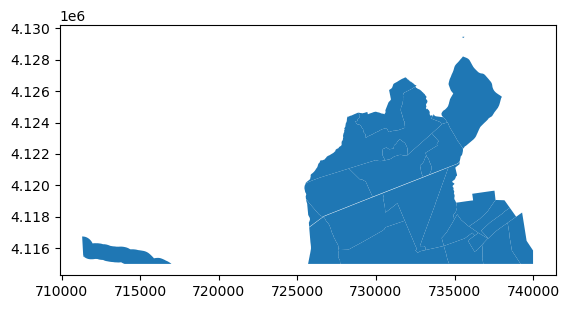

In [76]:
fincas_norte.plot()

### 4.5 Joins

In [82]:
# JOIN ATRIBUTUAL: como un merge de Pandas
# Añadir información extra a las fincas
info_extra = pd.DataFrame({
    'FINCA': ['ROCINA', 'ACEBUCHE', 'MADRE', 'MARISMILLAS'],
    'habitat': ['Marisma', 'Matorral mediterráneo', 'Corredor fluvial', 'Marisma'],
    'gestion': ['RENPA', 'RENPA', 'RENPA', 'RENPA']
})

fincas_info = fincas.merge(info_extra, on='FINCA', how='outer')
print(fincas_info[['FINCA', 'TITULARIDA', 'habitat']].dropna().head())

       FINCA TITULARIDA                habitat
1   ACEBUCHE    Pública  Matorral mediterráneo
38     MADRE    Pública       Corredor fluvial
55    ROCINA    Pública                Marisma


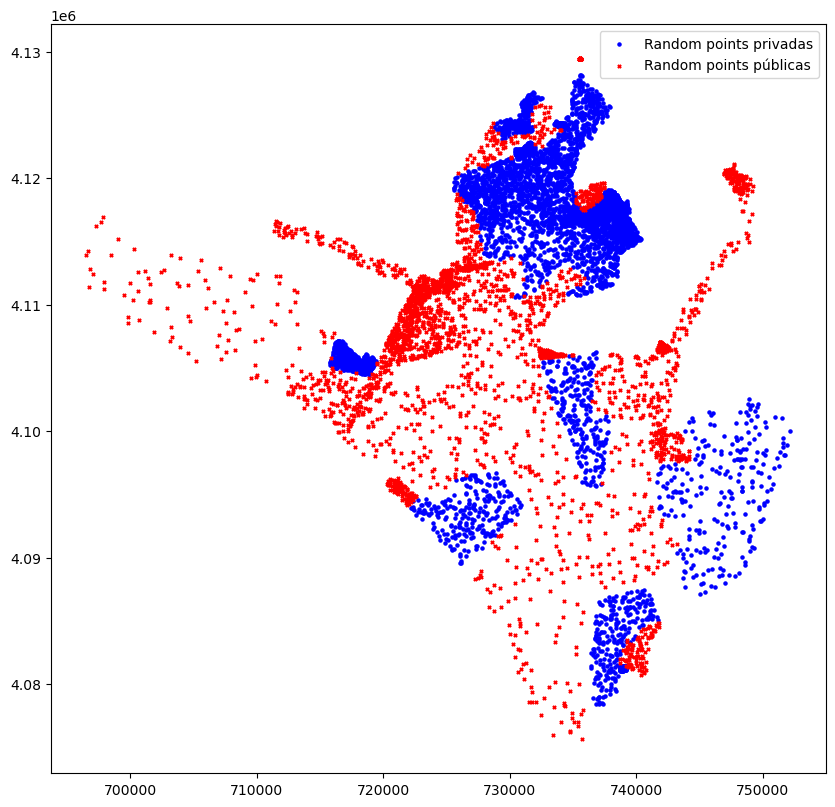

In [87]:
import matplotlib.pyplot as plt

data_sampled_points = privadas.sample_points(250)
data_sampled_points_sel = publicas.sample_points(100)

#Crear el mapa base
fig, ax = plt.subplots(figsize=(10, 10))

#Plotear ambos datasets en el mismo eje (ax)
data_sampled_points.plot(ax=ax, marker='o', color='blue', markersize=5, label='Random points privadas')
data_sampled_points_sel.plot(ax=ax, marker='x', color='red', markersize=5, label='Random points públicas')

#Añadir la leyenda
plt.legend()

#Mostrar el mapa
plt.show()

<Axes: >

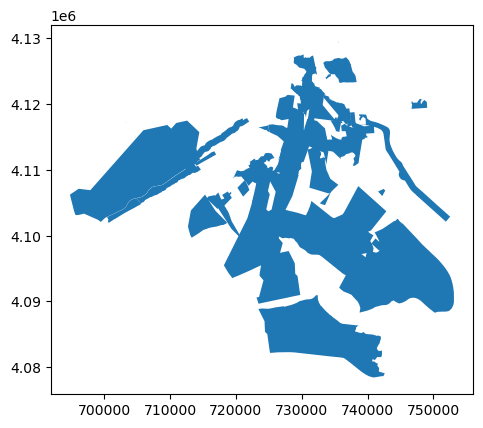

In [89]:
fincas.rotate(60).plot()


In [90]:
# SPATIAL JOIN: unir por relación espacial
# ¿Qué municipio contiene cada finca?
#municipios = gpd.read_file('../../data/13_01_TerminoMunicipal.shp')
fincas_muni = fincas.to_crs(andalucia.crs)  # mismo CRS

print(f'Columnas municipios: {andalucia.columns.tolist()}')

# predicate: 'intersects', 'within', 'contains', 'touches'
fincas_con_muni = gpd.sjoin(
    fincas_muni, andalucia,
    how='left',
    predicate='intersects'
)
print(f'\nResultado sjoin: {len(fincas_con_muni)} filas')
print(fincas_con_muni.columns.tolist())

Columnas municipios: ['id_dera', 'cod_mun', 'nombre', 'provincia', 'area', 'geometry']

Resultado sjoin: 95 filas
['OBJECTID', 'FINCA', 'TITULARIDA', 'Hectareas', 'Shape_Leng', 'Shape_Area', 'geometry', 'area_ha', 'perimetro', 'centroide', 'index_right', 'id_dera', 'cod_mun', 'nombre', 'provincia', 'area']


<Axes: >

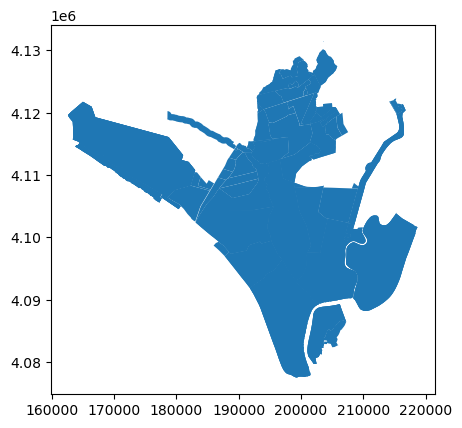

In [91]:
fincas_con_muni.plot()

### 4.6 Visualización básica

C:\Users\dvillegas.AULADEI\AppData\Local\Temp\ipykernel_9712\2024251624.py:27: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[2].legend()
C:\Users\dvillegas.AULADEI\AppData\Local\Temp\ipykernel_9712\2024251624.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


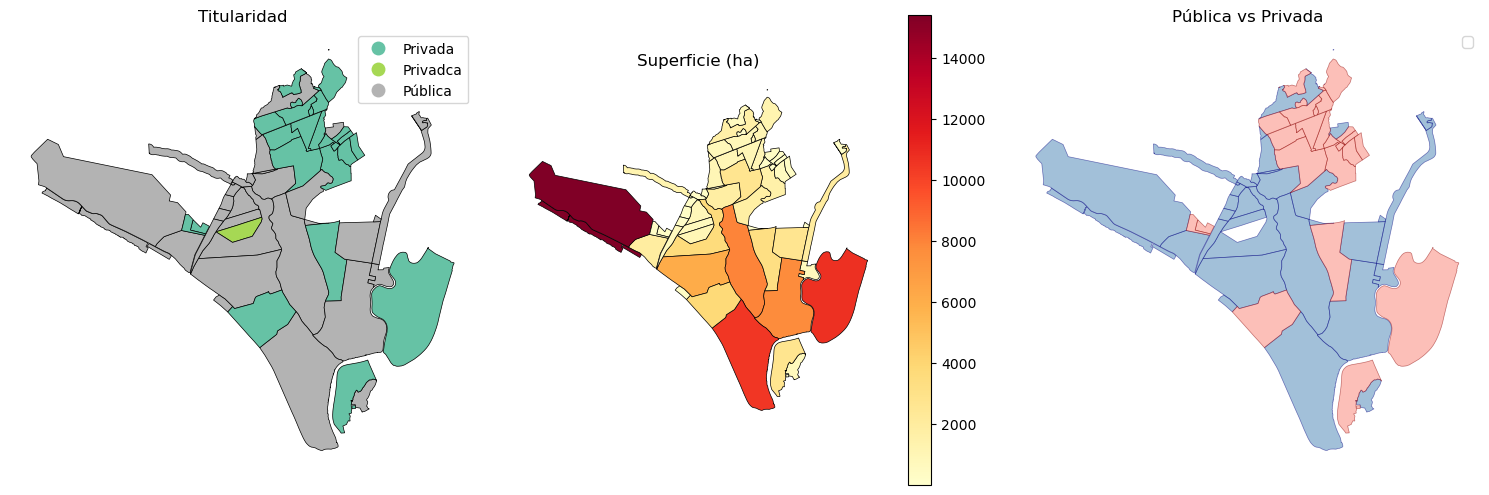

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Coloreado por atributo categórico
fincas.plot(ax=axes[0],
            column='TITULARIDA',
            categorical=True,
            legend=True,
            cmap='Set2',
            edgecolor='black',
            linewidth=0.5)
axes[0].set_title('Titularidad')

# 2. Coloreado por atributo numérico (choropleth)
fincas.plot(ax=axes[1],
            column='Hectareas',
            legend=True,
            cmap='YlOrRd',
            edgecolor='black',
            linewidth=0.5)
axes[1].set_title('Superficie (ha)')

# 3. Capas superpuestas
fincas[fincas['TITULARIDA']=='Pública'].plot(
    ax=axes[2], color='steelblue', alpha=0.5, edgecolor='navy', linewidth=0.5, label='Pública')
fincas[fincas['TITULARIDA']=='Privada'].plot(
    ax=axes[2], color='salmon', alpha=0.5, edgecolor='darkred', linewidth=0.5, label='Privada')
axes[2].legend()
axes[2].set_title('Pública vs Privada')

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
plt.show()

<Axes: >

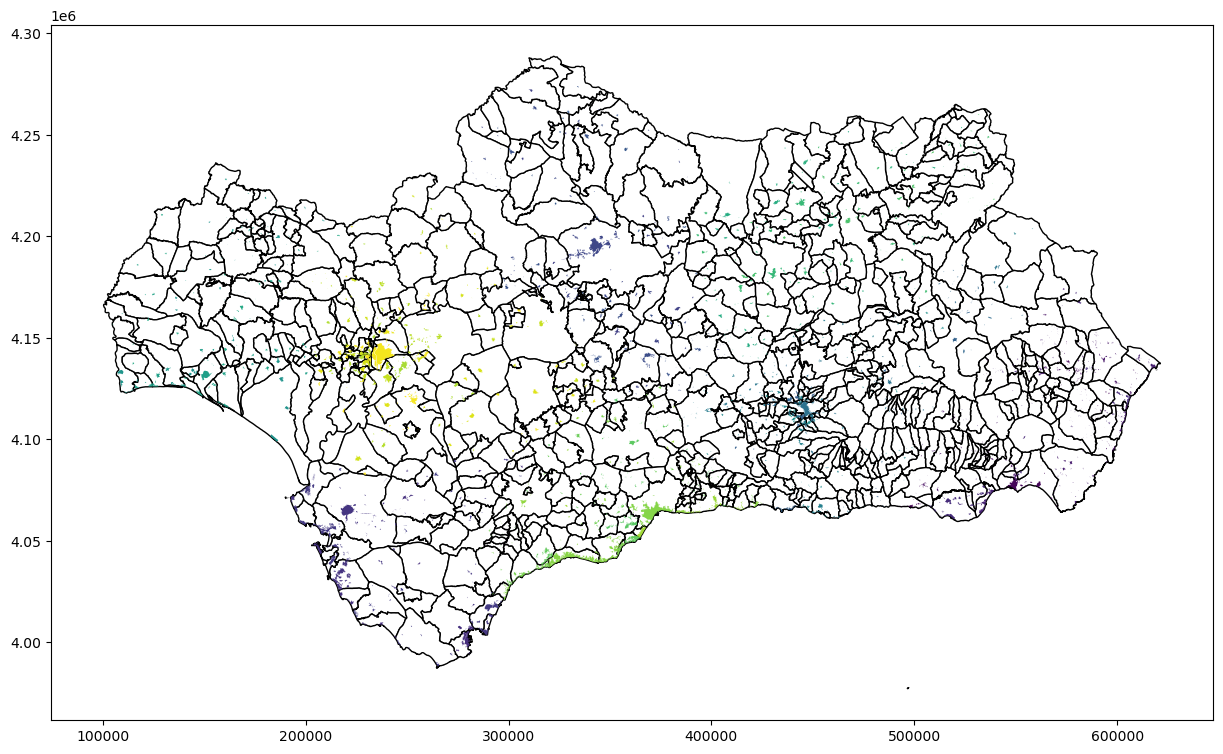

In [97]:
pueblos = gpd.read_file('C:/Users/dvillegas.AULADEI/Documents/Geopython_2026-main/data/07_01_NucleosUrbanos_pol.shp')

base= andalucia.plot(color='white', edgecolor='black', figsize=(15,10))
pueblos.plot(ax = base, column = 'cod_mun', cmap='viridis')
            # column='cod_mun',
            # categorical=True,
            # legend=False,
            # cmap='YlOrRd',
            # edgecolor='black',
            # linewidth=0.1,
            # figsize=(15, 5))
            # color

In [93]:
# Explore: mapa interactivo (Folium) con una sola línea
# (Funciona en Jupyter, no en algunos entornos de VS Code)
fincas.explore(
    column='TITULARIDA',
    cmap='Set2',
    tooltip=['FINCA', 'TITULARIDA', 'Hectareas'],
    tiles='CartoDB positron'
)

<Axes: >

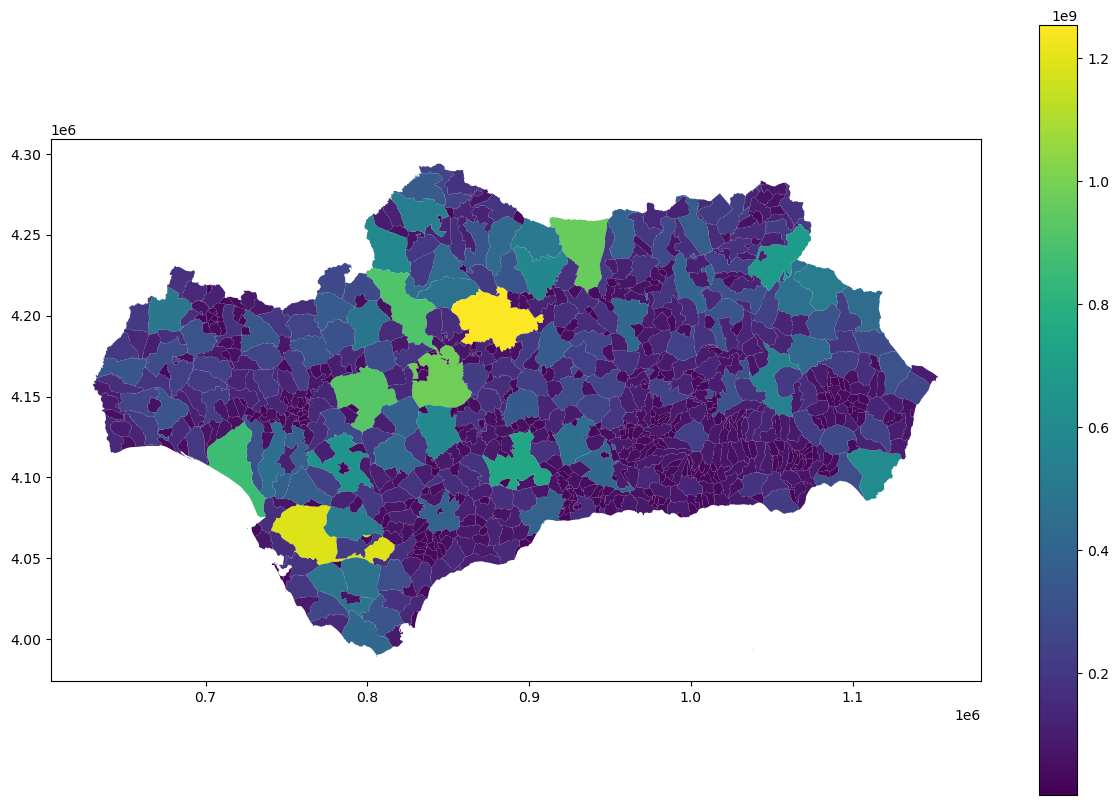

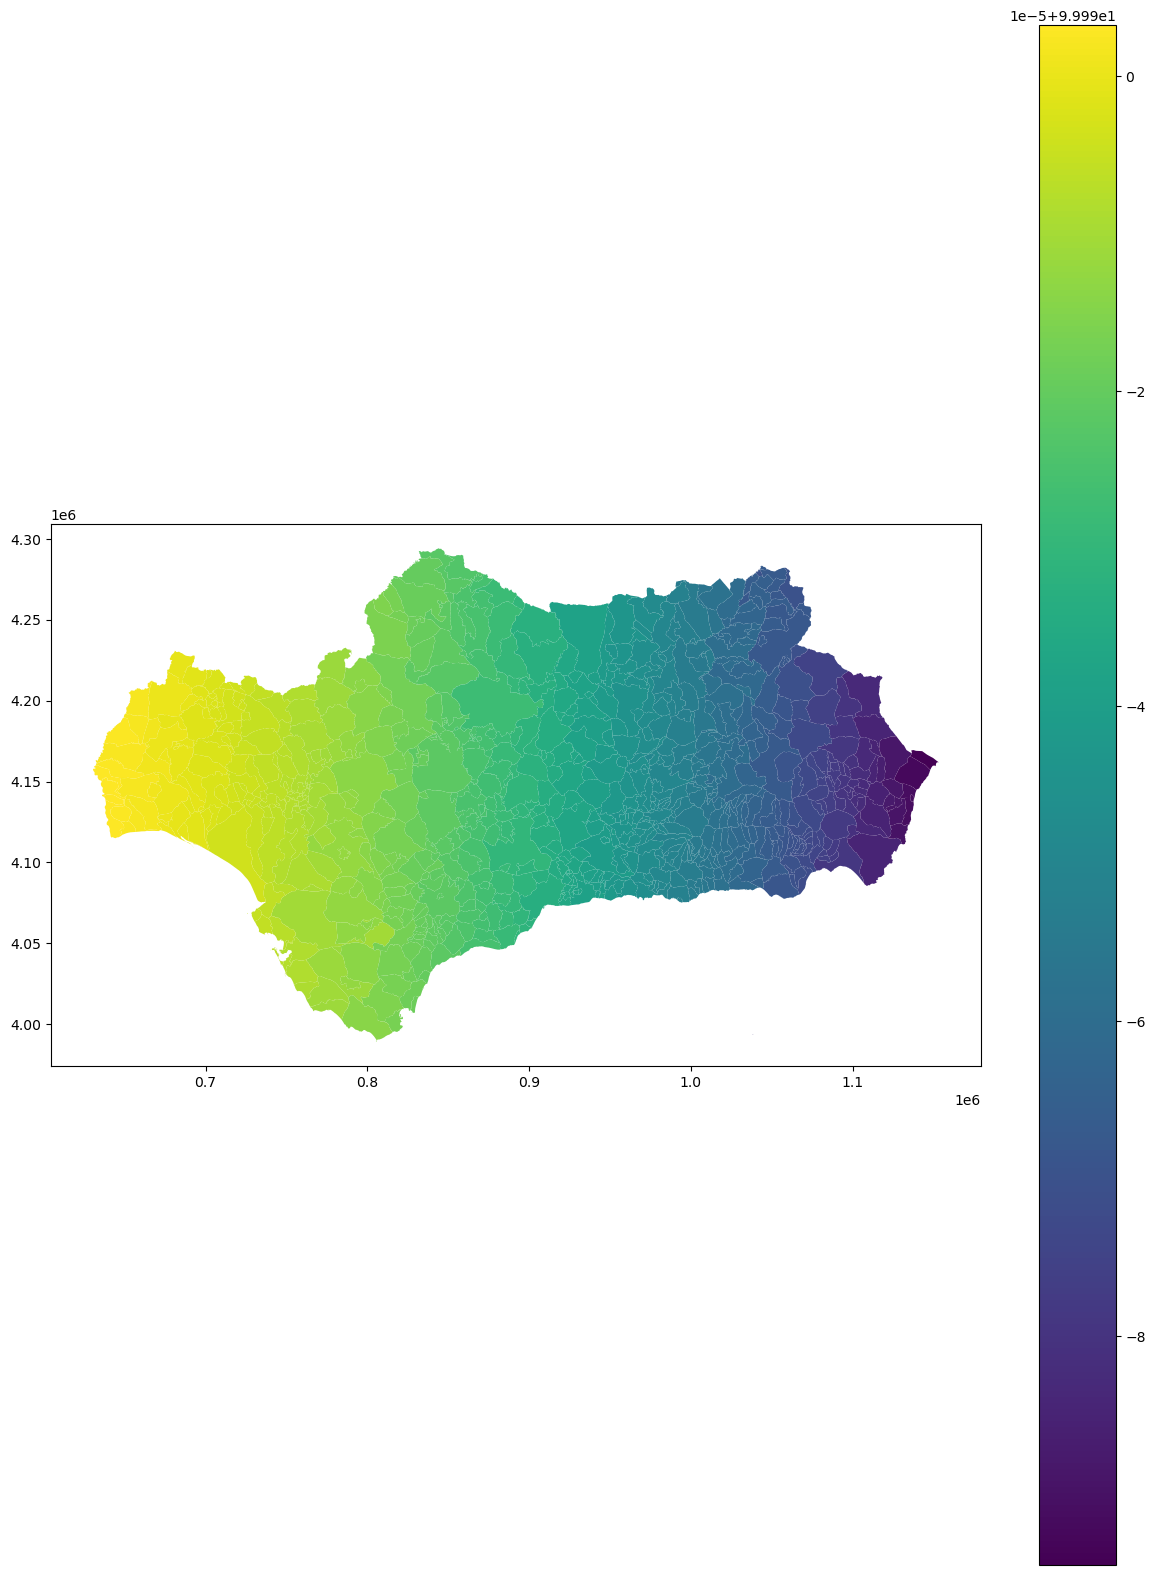

In [104]:
andalucia_29 = andalucia.to_crs(epsg=25829)  # ETRS89 UTM zona 29N
andalucia_29['area_29'] = andalucia_29['geometry'].area/10000

andalucia_29['dif_area'] = andalucia_29['area']-andalucia_29['area_29']
andalucia_29.head()
andalucia_29.plot('dif_area', legend=True, figsize=(15,10))

andalucia_29['dif_norm'] = andalucia_29['dif_area']*100/andalucia['area']
andalucia_29.plot('dif_norm', legend=True, figsize=(15,20))

---
## Resumen del día 2

| Librería | Lo que hace | Cuándo usarla |
|----------|-------------|---------------|
| **Shapely** | Geometrías y operaciones espaciales en memoria | Siempre que necesites geometría sin I/O |
| **Fiona** | Leer/escribir archivos vectoriales (sobre OGR) | Control fino de I/O, procesar sin cargar todo |
| **GeoPandas** | Análisis vectorial completo (Shapely + Pandas + I/O) | El día a día |

**Flujo habitual:**
```python
gdf = gpd.read_file('datos.shp')          # Fiona por debajo
gdf = gdf.to_crs(epsg=25830)              # pyproj por debajo
gdf['buffer'] = gdf.geometry.buffer(100)  # Shapely por debajo
resultado = gpd.sjoin(gdf, otra)          # Shapely por debajo
resultado.to_file('salida.gpkg')          # Fiona por debajo
```

**Mañana (Día 3):** GDAL/OGR → Numpy → Rasterio. La misma idea pero para datos raster.

---
*GeoPython 2026 — CSIC / Estación Biológica de Doñana*